In [1]:
# If not installed already (uncomment as needed):
# !pip install torch torch-geometric pandas tqdm

import os, json, torch, pandas as pd
from pathlib import Path
import importlib

import data_utils
importlib.reload(data_utils)

from data_utils import load_graphs, attach_labels_and_noisy, build_loaders
from train_loop import train, evaluate

In [2]:
# EDIT THESE:
GRAPHS_PT = "../processed/graphs_train.pt"      # <-- Step 1 output (a list[Data])
LABELS_CSV = "labels_train.csv"    # <-- We'll generate a template first if it doesn't exist
MODEL_OUT  = "qem_graph_transformer.pt"


In [3]:
graphs = load_graphs(GRAPHS_PT)
print(f"Loaded {len(graphs)} graphs")
# quick sanity on shapes
g0 = graphs[0]
print("x:", tuple(g0.x.shape),
      "edge_index:", tuple(g0.edge_index.shape),
      "lightcone_masks:", tuple(g0.lightcone_masks.shape))
M = g0.lightcone_masks.shape[1]
print("Measured qubits (M):", M)


Loaded 500 graphs
x: (2071, 20) edge_index: (2, 2565) lightcone_masks: (2071, 5)
Measured qubits (M): 5


In [4]:
# This will create a template with circuit_path + zero arrays for noisy_z/target_y (len = M).
# If LABELS_CSV already exists, this cell won’t overwrite it unless you set FORCE=True.
FORCE = False

if (not Path(LABELS_CSV).exists()) or FORCE:
    rows = []
    for g in graphs:
        path = g.circuit_path if isinstance(g.circuit_path, str) else g.circuit_path[0]
        # Placeholder arrays (fill these with your real noisy/ideal values):
        zeros = [0.0] * g.lightcone_masks.shape[1]
        rows.append({
            "circuit_path": path,
            "noisy_z_json": json.dumps(zeros),
            "target_y_json": json.dumps(zeros)
        })
    df = pd.DataFrame(rows)
    df.to_csv(LABELS_CSV, index=False)
    print(f"Template written to {LABELS_CSV} with {len(df)} rows and M={M}.")
    display(df.head(3))
else:
    print(f"{LABELS_CSV} already exists — not overwriting. Set FORCE=True to regenerate.")


labels_train.csv already exists — not overwriting. Set FORCE=True to regenerate.


In [19]:
# Make sure you've filled LABELS_CSV before running this cell.
graphs, M = attach_labels_and_noisy(graphs, LABELS_CSV)  # validates M consistency
print(f"Graphs ready with labels. M={M}")

train_loader, val_loader = build_loaders(graphs, batch_size=4, val_frac=0.8, seed=42)
len(train_loader), len(val_loader)


Graphs ready with labels. M=5


(25, 100)

In [20]:
iterator = iter(train_loader)
batch = next(iterator)

In [21]:
batch

DataBatch(x=[50564, 20], edge_index=[2, 62935], num_nodes=50564, lightcone_masks=[50564, 5], measured_qubits=[20], num_measured=[4], num_qubits=[4], depth_layers=[4], circuit_path=[4], split=[4], noisy_z=[20], y=[20], batch=[50564], ptr=[5])

In [30]:
# You can tune these a bit; keep it small because of low data.
model_cfg = dict(d_model=128, layers=3, heads=4, dropout=0.2, use_noisy=True)

net = train(
    model_cfg,
    (train_loader, val_loader),
    epochs=100,
    lr=1e-3,
    wd=1e-4,
    patience=15,  # early stopping
)
# torch.save(net.state_dict(), MODEL_OUT)
# print("Saved:", MODEL_OUT)


Epoch 001 | train 0.0899 | val 0.0492 | MAE 0.2439
Epoch 002 | train 0.0580 | val 0.0472 | MAE 0.2322
Epoch 003 | train 0.0531 | val 0.0400 | MAE 0.2058
Epoch 004 | train 0.0506 | val 0.0383 | MAE 0.1886
Epoch 005 | train 0.0482 | val 0.0346 | MAE 0.1787
Epoch 006 | train 0.0446 | val 0.0385 | MAE 0.2184
Epoch 007 | train 0.0411 | val 0.0396 | MAE 0.2273
Epoch 008 | train 0.0398 | val 0.0376 | MAE 0.2178
Epoch 009 | train 0.0363 | val 0.0228 | MAE 0.1440
Epoch 010 | train 0.0353 | val 0.0258 | MAE 0.1686
Epoch 011 | train 0.0294 | val 0.0166 | MAE 0.1263
Epoch 012 | train 0.0249 | val 0.0151 | MAE 0.1316
Epoch 013 | train 0.0151 | val 0.0207 | MAE 0.1749
Epoch 014 | train 0.0163 | val 0.0066 | MAE 0.0835
Epoch 015 | train 0.0100 | val 0.0028 | MAE 0.0478
Epoch 016 | train 0.0081 | val 0.0021 | MAE 0.0539
Epoch 017 | train 0.0048 | val 0.0013 | MAE 0.0348
Epoch 018 | train 0.0045 | val 0.0013 | MAE 0.0422
Epoch 019 | train 0.0041 | val 0.0088 | MAE 0.1265
Epoch 020 | train 0.0032 | val 

In [31]:
import torch.nn as nn
crit = nn.SmoothL1Loss()
device = "cuda" if torch.cuda.is_available() else "cpu"
metrics = evaluate(net, val_loader, crit, device=device)
metrics


{'loss': 0.0004417332648881711, 'mae': 0.023918342024087907}

In [32]:
import torch
from torch_geometric.loader import DataLoader

net.eval()
mae_sum = torch.zeros(M)
count   = torch.zeros(M)
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        y_hat = net(batch)   # [B*M] if collated, but because M is constant, shapes align per graph
        y     = batch.y
        # unfold graph-level dimension using PyG's batch metadata: val_loader won't provide per-graph M directly.
        # Since M is constant, we can reshape by M:
        m = M
        y_hat = y_hat.view(-1, m)
        y     = y.view(-1, m)
        mae_sum += (y_hat - y).abs().sum(dim=0).cpu()
        count   += torch.ones_like(mae_sum) * y.shape[0]

per_qubit_mae = (mae_sum / torch.clamp(count, min=1)).tolist()
per_qubit_mae


[0.0244296845048666,
 0.024109072983264923,
 0.023978829383850098,
 0.023913580924272537,
 0.02316053956747055]

/tmp/ipykernel_42765/3271494236.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


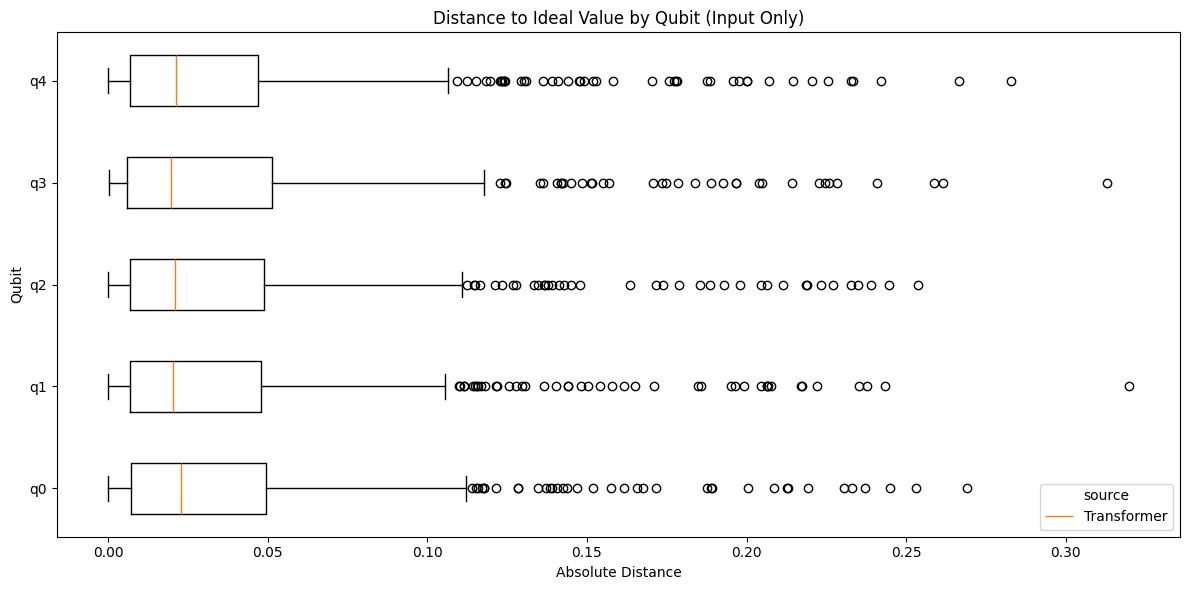

In [33]:
# Step 9 — Distance-to-ideal by qubit, grouped horizontal boxplots (matplotlib only)

import torch
import matplotlib.pyplot as plt

def collect_matrix(loader, attr, M=None):
    """Stack a [S, M] matrix from a DataLoader for a given tensor attribute name."""
    chunks = []
    for b in loader:
        chunks.append(getattr(b, attr).detach().cpu())
    flat = torch.cat(chunks, dim=0)
    if M is None:
        # infer M from first batch
        M = next(iter(loader)).lightcone_masks.shape[1]
    return flat.view(-1, M)  # [S, M]

def plot_distance_boxplot(dist_by_source, qubit_labels=None, title="Distance to Ideal Value by Qubit"):
    """
    dist_by_source: dict{name -> torch.Tensor [S, M]} where entries are |something - ideal|
    qubit_labels: list like ['q0','q1',...]; defaults to q0..q{M-1}
    """
    # infer M
    first = next(iter(dist_by_source.values()))
    S, M = first.shape
    if qubit_labels is None:
        qubit_labels = [f"q{i}" for i in range(M)]

    sources = list(dist_by_source.keys())
    K = len(sources)

    fig = plt.figure(figsize=(12, 6))
    ax = plt.gca()

    # y positions: one row per qubit, but split into K side-by-side positions
    base_positions = torch.arange(M).float()  # 0..M-1
    # small offset so boxes for the same qubit don't overlap
    offset = 0.25
    offsets = torch.linspace(-offset, offset, steps=K) if K > 1 else torch.tensor([0.0])

    # Collect handles for legend
    handles = []
    for j, name in enumerate(sources):
        D = dist_by_source[name]  # [S, M]
        # Build per-qubit boxplot data
        data = [D[:, q].numpy() for q in range(M)]
        positions = (base_positions + offsets[j]).tolist()
        bp = ax.boxplot(
            data,
            positions=positions,
            vert=False,           # horizontal
            widths=0.5,
            patch_artist=False,   # no custom colors per policy
            manage_ticks=False,
            whis=1.5,
            labels=None
        )
        # Keep one handle per source for legend (use median line as proxy)
        handles.append(bp['medians'][0])

    # Y ticks at the center of each qubit row
    ax.set_yticks(base_positions.tolist())
    ax.set_yticklabels(qubit_labels)

    ax.set_xlabel("Absolute Distance")
    ax.set_ylabel("Qubit")
    ax.set_title(title)
    ax.legend(handles, sources, loc="lower right", title="source")
    fig.tight_layout()
    plt.show()

# ---- Example usage ----
# Distances for "Input Only" (noisy vs ideal) on the validation set:
M_val = next(iter(val_loader)).lightcone_masks.shape[1]
noisy_mat  = collect_matrix(val_loader, "noisy_z", M=M_val)   # [S, M]
ideal_mat  = collect_matrix(val_loader, "y",       M=M_val)   # [S, M]
dist_input = (noisy_mat - ideal_mat).abs()                    # [S, M]

# If you have model predictions, make similar matrices and take abs diff vs ideal:
# pred_mat_tx = collect_model_preds(val_loader, net)          # you’d implement this
# dist_tx     = (pred_mat_tx - ideal_mat).abs()
# dist_rf     = (pred_mat_rf - ideal_mat).abs()
# dist_clip   = (pred_mat_clip - ideal_mat).abs()

# Plot exactly like your example (use whatever sources you have):
plot_distance_boxplot(
    {
        # "CLIP+Transformer": dist_clip,
        # "RandomForests":    dist_rf,
        "Transformer":       dist_input,  # replace with your model distances when ready
    },
    qubit_labels=[f"q{i}" for i in range(M_val)],
    title="Distance to Ideal Value by Qubit (Input Only)"
)
